In [73]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [74]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key=os.getenv("GROQ_API_KEY")


In [52]:
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

In [75]:
##Initialise chat model
from langchain.chat_models import init_chat_model

model = init_chat_model("openai/gpt-oss-120b", model_provider="GROQ")
model


##State
class AgentState(MessagesState):
    next_agent: str  ##Which agent should go next

In [76]:
##Create a Simple tool

@tool
def search_web(query:str)->str:
    """Search the web for information"""
    search=TavilySearchResults(max_results=2)
    result=search.invoke(query)
    return str(result)

In [77]:
##Tool 2- write the summary
@tool
def write_summary(content:str)->str:
    """write the summary based on the content provided"""

    summary=f"Summary of the findings :\n\n{content[:500]}"
    return summary


In [78]:
def research_agent(state:AgentState):
    messages=state["messages"]

    ##Def System messages
    system_message=SystemMessage(content="You are the research assistant user search web tool to find th information about user messages")

    llm_tool_call=model.bind_tools(tools=[search_web])
    response=llm_tool_call.invoke([system_message]+messages)

    return{"messages":[response], "next_agent":"writer"}


In [79]:
def write_agent(state:AgentState):
    """writer agent create the summary"""
    messages=state["messages"]

    ##Add System message
    system_message=SystemMessage(content="You are the technical writer. Review the conversation and create the summary")
    llm_tool_call=model.bind_tools(tools=[write_agent])
    ##Simple completion without tools
    response=llm_tool_call.invoke([system_message]+messages)
    return{"messages":[response],"next_agent":"END"}

In [80]:
##Tool executor node

def execute_tools(state : AgentState): 
    """Execute any pending tool calls"""
    messages=state["messages"]
    last_message=messages[-1]

    ##Check if there are tool call to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        ##Create tool node to execute
        tool_node=ToolNode([search_web,write_summary])
        response=tool_node.invoke(state)
        return response
    #No tools to execute
    return state


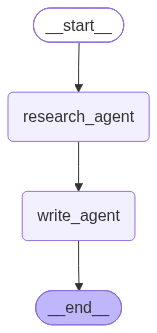

In [81]:
#Build the workflow
workflow=StateGraph(MessagesState)

## Add nodes 
workflow.add_node("research_agent", research_agent)
workflow.add_node("write_agent", write_agent)

##Define flow
workflow.set_entry_point("research_agent")
workflow.add_edge("research_agent","write_agent")
workflow.add_edge("write_agent", END)

##Compile the work flow
final_workflow=workflow.compile()
final_workflow



In [85]:
response=final_workflow.invoke({"messages":"What is latest new in AI?"})

In [94]:
response["messages"][:-1]

[HumanMessage(content='What is latest new in AI?', additional_kwargs={}, response_metadata={}, id='b37b6ff0-334d-4a36-bdbe-597b60ba1a38'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is latest new in AI?" Likely they want recent AI news. Need to browse web to get latest AI developments. Use search.', 'tool_calls': [{'id': 'fc_e55d60e8-8086-4711-8572-eaf21eb5c262', 'function': {'arguments': '{"query":"latest AI news September 2026"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 146, 'total_tokens': 213, 'completion_time': 0.141120996, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.006587706, 'prompt_tokens_details': None, 'queue_time': 0.346375604, 'total_time': 0.147708702}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_068241849b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider':

Supervised multistate agent


In [121]:
from langchain_core.prompts import ChatPromptTemplate

# =====================================
# State Definition
# =====================================


class SupervisorState(MessagesState):
    """State for the multi-agent system"""

    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [122]:
# ================================
# Supervisor with Groq LLM
# ================================


def create_supervisor_chain():
    """Creates the supervisor decision chain"""

    supervisor_prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """You are a supervisor managing a team of agents:

1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
""",
            ),
            ("human", "{task}"),
        ]
    )

    return supervisor_prompt | model

In [123]:
from typing import Dict

def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""

    messages = state["messages"]
    task = messages[-1].content if messages else "No task"

    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))

    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke(
        {
            "task": task,
            "has_research": has_research,
            "has_analysis": has_analysis,
            "has_report": has_report,
        }
    )

    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)

    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."

    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = (
            "📄 Supervisor: Let's start with research. Assigning to Researcher..."
        )

    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = (
            "📄 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
        )

    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📄 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."

    else:
        next_agent = "end"

    supervisor_msg = "✅ Supervisor: Task seems complete."

    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task,
    }

In [124]:
# ====================================
# Agent 1: Researcher (using Groq)
# ====================================


def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""

    task = state.get("current_task", "research topic")

    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

Include:
1. Key facts and background
2. Current trends or developments
3. Important statistics or data points
4. Notable examples or case studies

Be concise but thorough."""

    # Get research from LLM
    research_response = model.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content

    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data}"

    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor",
    }

In [130]:
# ====================================
# Agent 3: Writer (using Groq)
# ====================================
from datetime import datetime

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""

    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")

    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

    Task: {task}

    Research Findings:
    {research_data[:1000]}

    Analysis:
    {analysis[:1000]}

    Create a well-structured report with:
    1. Executive Summary
    2. Key Findings
    3. Analysis & Insights
    4. Recommendations
    5. Conclusion

    Keep it professional and concise."""


    # Get report from LLM
    report_response = model.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content

    # Create final formatted report
    final_report = f"""
    📄 FINAL REPORT
    {'='*50}
    Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
    Topic: {task}
    {'='*50}

    {report}

    {'='*50}
    Report compiled by Multi-Agent AI System powered by Groq
    """
    return {
        "messages": [
            AIMessage(
                content=f"✍️ Writer: Report complete! See below for the full document."
            )
        ],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True,
    }

In [126]:
# ====================================
# Agent 2: Analyst (using Groq)
# ====================================


def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""

    research_data = state.get("research_data", "")
    task = state.get("current_task", "")

    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""

    # Get analysis from LLM
    analysis_response = model.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content

    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."

    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor",
    }

In [127]:
# ====================================
# Router Function
# ====================================


def router(
    state: SupervisorState,
) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""

    next_agent = state.get("next_agent", "supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END

    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent

    return "supervisor"

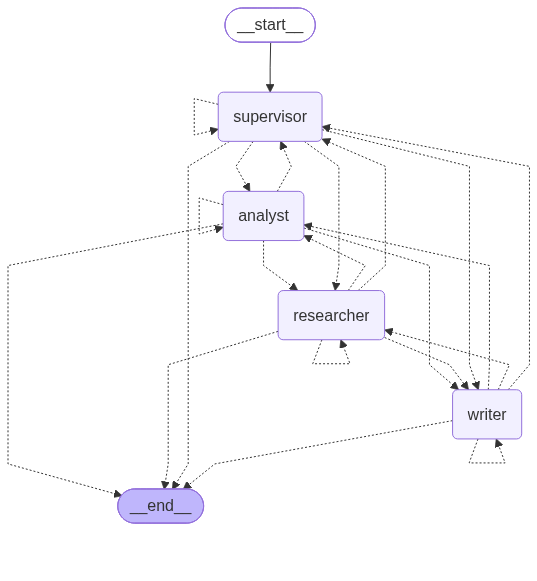

In [128]:
# ====================================
# Create workflow
# ====================================

workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END,
        },
    )

graph=workflow.compile()
graph

In [133]:
graph.invoke({"messages":"What are the Benifits and risks of AI in healthcare?"})

researcher
analyst
writer


{'messages': [HumanMessage(content='What are the Benifits and risks of AI in healthcare?', additional_kwargs={}, response_metadata={}, id='fd288c10-bbcc-428c-bef7-2703c291fa8d'),
  AIMessage(content='✅ Supervisor: Task seems complete.', additional_kwargs={}, response_metadata={}, id='12160f74-3b51-47ef-99df-d236dab96fe6', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="🔍 Researcher: I've completed the research on 'What are the Benifits and risks of AI in healthcare?'.\n\nKey findings:\n**AI in Healthcare – Benefits & Risks**  \n*(Compiled from peer‑reviewed literature, industry reports, and regulatory guidance up to\u202f2024)*  \n\n---\n\n## 1. Key Facts & Background  \n\n| Aspect | Detail |\n|--------|--------|\n| **Definition** | AI = machine‑learning (ML), deep‑learning (DL), natural‑language processing (NLP), and symbolic‑AI systems that can ingest, analyse, and act on health‑related data. |\n| **Regulatory Landscape** | FDA (U.S.) classifies many AI‑based software as 